**Purpose:** Returns-prediction results.

**Outputs:** `thesis/figs/reddit_token_distribution.png`, `thesis/figs/returns_metrics_violin.png`

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT


# box + swarm (or strip) plot

# lstm returns results

In [28]:
import pandas as pd

news_ensemble = {
   "Sector": ["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"],
   "MSE": [0.000113, 0.000130, 0.000191, 0.000112, 0.000107, 0.000238, 0.000059, 0.000128, 0.000117, 0.000074, 0.000190],
   "RMSE": [0.010610, 0.011380, 0.013821, 0.010588, 0.010321, 0.015419, 0.007713, 0.011317, 0.010823, 0.008615, 0.013770],
   "MAPE": [1.215021, 1.327688, 1.560686, 1.236375, 1.373877, 1.361408, 1.081716, 1.098037, 1.136411, 1.743391, 1.091392],
}

reddit_ensemble = {
   "Sector": ["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"],
   "MSE": [0.000115, 0.000131, 0.000189, 0.000110, 0.000110, 0.000235, 0.000061, 0.000138, 0.000123, 0.000076, 0.000188],
   "RMSE": [0.010717, 0.011447, 0.013766, 0.010506, 0.010469, 0.015341, 0.007842, 0.011753, 0.011083, 0.008694, 0.013719],
   "MAPE": [1.478052, 1.850672, 1.828886, 1.313216, 1.559459, 1.527458, 1.179476, 1.369889, 1.675278, 1.801262, 1.234454],
}

redditnews_ensemble = {
   "Sector": ["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"],
   "MSE": [0.000115, 0.000127, 0.000191, 0.000110, 0.000110, 0.000238, 0.000063, 0.000140, 0.000119, 0.000077, 0.000187],
   "RMSE": [0.010715, 0.011291, 0.013818, 0.010511, 0.010470, 0.015420, 0.007907, 0.011815, 0.010930, 0.008799, 0.013670],
   "MAPE": [1.507782, 1.448490, 1.667498, 1.374121, 1.705888, 1.629931, 1.301974, 1.327685, 1.572532, 1.639835, 1.258352],
}

tech_ensemble = {
   "Sector": ["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"],
   "MSE": [0.000114, 0.000129, 0.000194, 0.000113, 0.000110, 0.000240, 0.000059, 0.000132, 0.000116, 0.000072, 0.000191],
   "RMSE": [0.010661, 0.011359, 0.013933, 0.010635, 0.010497, 0.015488, 0.007703, 0.011488, 0.010790, 0.008487, 0.013823],
   "MAPE": [1.196753, 1.288276, 1.462920, 1.371775, 1.276080, 1.163317, 1.168637, 1.092961, 1.179103, 1.146165, 1.026711],
}

news_ensemble["source"] = ["GDELT"] * len(news_ensemble["Sector"])
reddit_ensemble["source"] = ["Reddit"] * len(reddit_ensemble["Sector"])
redditnews_ensemble["source"] = ["GDELT+Reddit"] * len(redditnews_ensemble["Sector"])
tech_ensemble["source"] = ["Technical"] * len(tech_ensemble["Sector"])

df = pd.DataFrame(tech_ensemble)
df = pd.concat([df, pd.DataFrame(news_ensemble)], ignore_index=True)
df = pd.concat([df, pd.DataFrame(reddit_ensemble)], ignore_index=True)
df = pd.concat([df, pd.DataFrame(redditnews_ensemble)], ignore_index=True)
   
sectors = ['XLE', 'XLB', 'XLI', 'XLY', 'XLP', 'XLV', 'XLF', 'XLK', 'XLC', 'XLU', 'XLRE']
df["Sector"] = pd.Categorical(df["Sector"], categories=sectors, ordered=True)
df = df.sort_values("Sector").reset_index(drop=True)

sources = ["Technical", "GDELT", "Reddit", "GDELT+Reddit"]
df["source"] = pd.Categorical(df["source"], categories=sources, ordered=True)
df = df.sort_values("source").reset_index(drop=True)

df.head()

,Sector,MSE,RMSE,MAPE,source
0,XLE,0.000194,0.013933,1.462920,Technical
1,XLU,0.000116,0.010790,1.179103,Technical
2,XLC,0.000129,0.011359,1.288276,Technical
3,XLK,0.000240,0.015488,1.163317,Technical
4,XLF,0.000113,0.010635,1.371775,Technical


In [29]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Match your thesis: Latin Modern via LaTeX rendering
mpl.rcParams.update({
    # Use LaTeX for all text rendering
    "text.usetex": True,
    "font.family": "serif",

    # Latin Modern — matches your \usepackage{lmodern}
    "font.serif": ["Latin Modern Roman"],
    "font.sans-serif": ["Latin Modern Sans"],   # matches \sffamily in headings
    "font.monospace": ["Latin Modern Mono"],    # matches your TTT font

    # Match your thesis font size (11pt base)
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Load lmodern in the LaTeX preamble — critical for matching
    "pgf.preamble": "\n".join([
        r"\usepackage[utf8]{inputenc}",
        r"\usepackage[T1]{fontenc}",
        r"\usepackage{lmodern}",
    ]),

    # Line spacing loosely mirrors your \linespread{1.5}
    "figure.dpi": 600,
})


# plt.figure(figsize=(5.71*1.5, 3.5))

# # ...

# plt.tight_layout()
# # plt.savefig(str(PROJECT_ROOT / "thesis/figs/reddit_token_distribution.png"), bbox_inches="tight")
# plt.show()

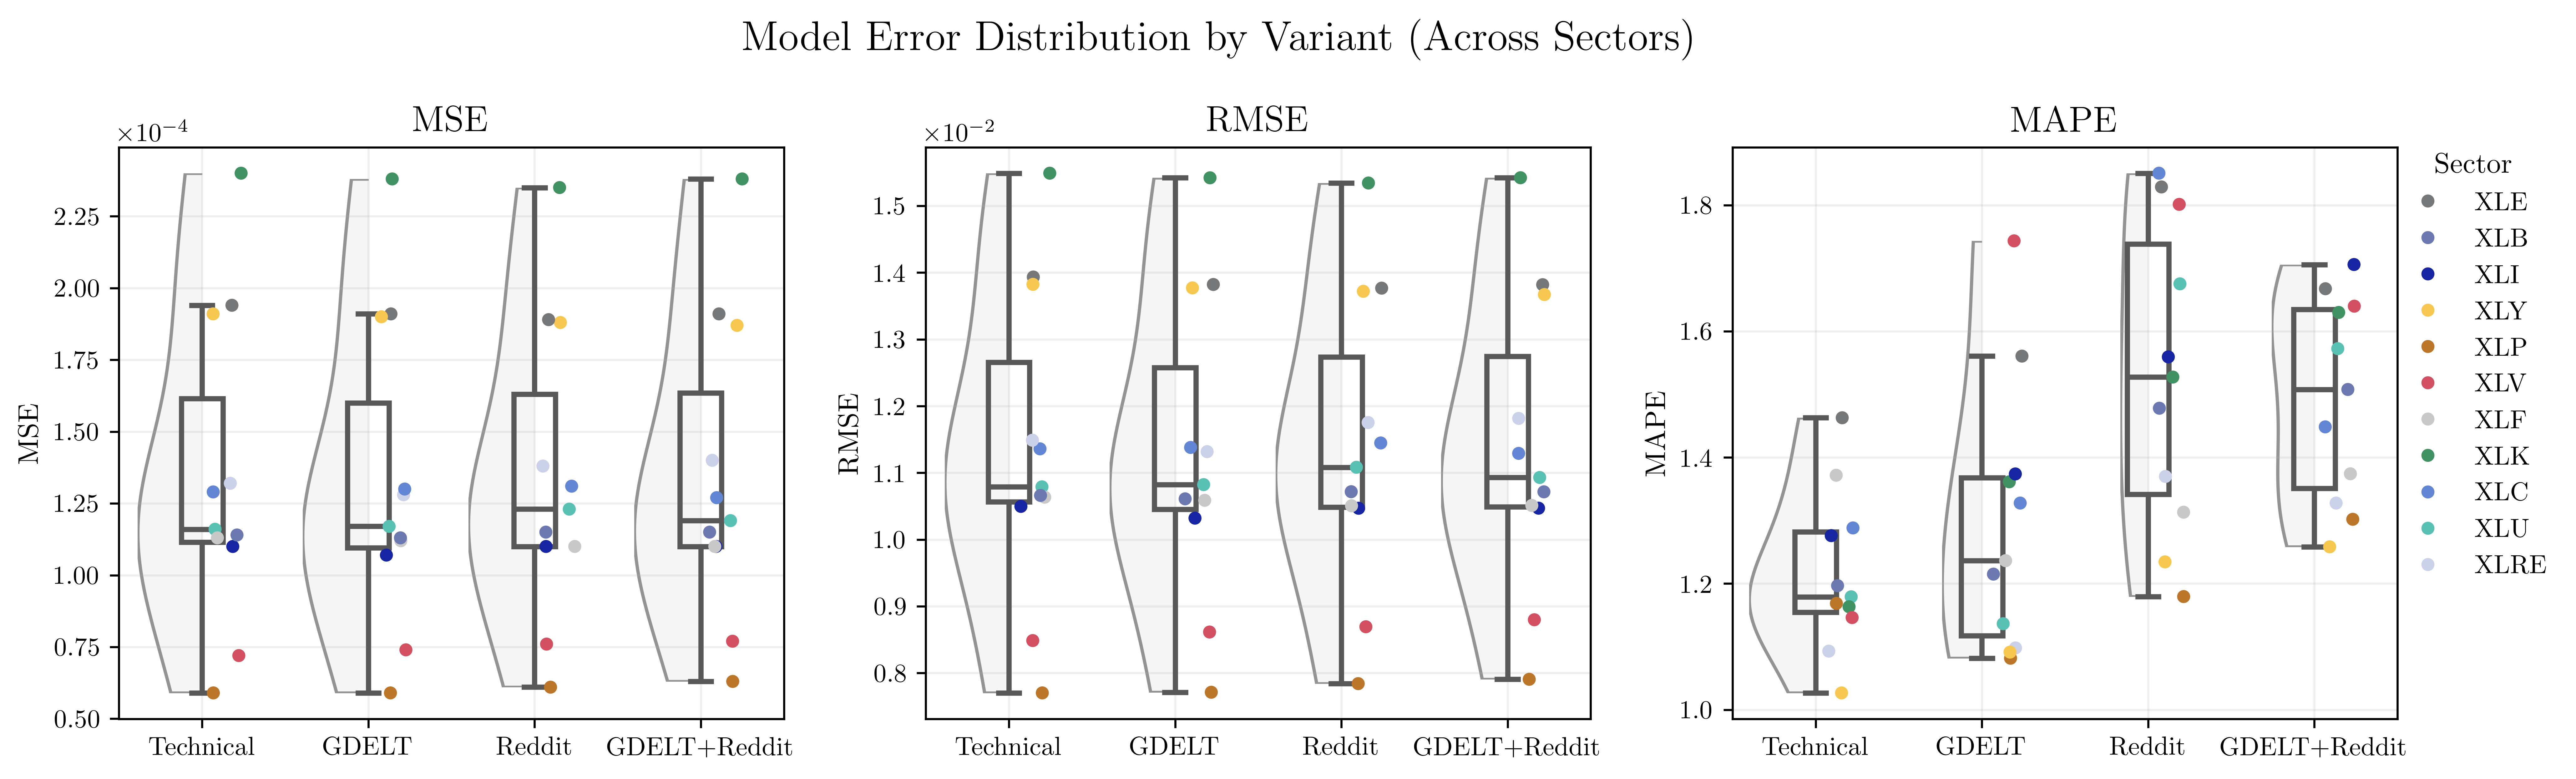

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

#sectors = ["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"]
#palette = dict(zip(sectors, sns.color_palette("Paired", 11)))

sectors = ['XLE', 'XLB', 'XLI', 'XLY', 'XLP', 'XLV', 'XLF', 'XLK', 'XLC', 'XLU', 'XLRE']
palette = {
    "XLE":  "#767779",   # Energy           rgb(118, 119, 122)
    "XLB":  "#6C79B1",   # Materials        rgb(108, 121, 177)
    "XLI":  "#1725A3",   # Industrials      rgb(23,  37,  163)
    "XLY":  "#F6C84F",   # Consumer Disc.   rgb(246, 200, 79)
    "XLP":  "#BB762A",   # Consumer Staples rgb(187, 118, 42)
    "XLV":  "#D35063",   # Health Care      rgb(211, 80,  99)
    "XLF":  "#C8C8C8",   # Financials       rgb(200, 200, 200)
    "XLK":  "#419262",   # Technology       rgb(65,  146, 98)
    "XLC":  "#6286D4",   # Comm. Services   rgb(98,  134, 212)
    "XLU":  "#58C1B3",   # Utilities        rgb(88,  193, 179)
    "XLRE": "#CBD1E8",   # Real Estate      rgb(203, 209, 232)
}

metrics = ["MSE", "RMSE", "MAPE"]

fig, axes = plt.subplots(1, 3, figsize=(5.71*2.3, 3.5*1.2))

for ax, metric in zip(axes, metrics):
    
    # --- VIOLIN ---
    sns.violinplot(
        x='source',
        y=metric,
        data=df,
        ax=ax,
        color='whitesmoke',
        cut=0,
        inner=None
    )

    # Clip to half violin
    for item in ax.collections:
        try:
            x0, y0, width, height = item.get_paths()[0].get_extents().bounds
            item.set_clip_path(
                patches.Rectangle(
                    (x0, y0),
                    width/2,
                    height,
                    transform=ax.transData
                )
            )
        except:
            pass

    # Store number of violin elements
    num_items = len(ax.collections)

    # --- SCATTER (SECTORS) ---
    sns.stripplot(
        x='source',
        y=metric,
        data=df,
        ax=ax,
        hue='Sector',
        palette=palette,   # 👈 consistent colors
        color='black',   # cleaner than many colors
        jitter=True,
        alpha=1,
        size=5
    )

    # Shift scatter slightly to the right
    for item in ax.collections[num_items:]:
        offsets = item.get_offsets()
        item.set_offsets(offsets + [0.15, 0])

    # --- BOX PLOT ---
    sns.boxplot(
        x='source',
        y=metric,
        data=df,
        ax=ax,
        width=0.25,
        showfliers=False,
        showmeans=True,
        meanprops=dict(
            marker='o',
            markerfacecolor='white',
            markersize=0,
            zorder=-1
        ),
        boxprops=dict(
            facecolor=(0,0,0,0),
            linewidth=2
        ),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2),
        medianprops=dict(linewidth=2)
    )

    # Remove legends for all but last subplot
    if metric != metrics[-1]:
        ax.get_legend().remove()
    else:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

    # --- Cosmetics ---
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_title(metric, fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.2)

    

fig.legend(
    handles,
    labels,
    title="Sector",
    bbox_to_anchor=(.97, .24),
    loc='lower left',
    frameon=False
)

plt.suptitle("Model Error Distribution by Variant (Across Sectors)", fontsize=16)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "thesis/figs/returns_metrics_violin.png"), bbox_inches="tight")
plt.show()